## 텐서플로우를 이용한 신경망
- 직접 신경망과 층을 궁현하지 않고 Sequential, Dense를 사용
- <img src="img/zp.png" width="400">

Epoch 1/40
1500/1500 [==============================] - 3s 2ms/step - loss: 1.3952 - accuracy: 0.6456 - val_loss: 0.9675 - val_accuracy: 0.7464
Epoch 2/40
1500/1500 [==============================] - 3s 2ms/step - loss: 0.8442 - accuracy: 0.7453 - val_loss: 0.7507 - val_accuracy: 0.7621
Epoch 3/40
1500/1500 [==============================] - 3s 2ms/step - loss: 0.7105 - accuracy: 0.7653 - val_loss: 0.6615 - val_accuracy: 0.7802
Epoch 4/40
1500/1500 [==============================] - 3s 2ms/step - loss: 0.6449 - accuracy: 0.7820 - val_loss: 0.6101 - val_accuracy: 0.7944
Epoch 5/40
1500/1500 [==============================] - 3s 2ms/step - loss: 0.6028 - accuracy: 0.7940 - val_loss: 0.5744 - val_accuracy: 0.8037
Epoch 6/40
1500/1500 [==============================] - 3s 2ms/step - loss: 0.5728 - accuracy: 0.8040 - val_loss: 0.5488 - val_accuracy: 0.8105
Epoch 7/40
1500/1500 [==============================] - 3s 2ms/step - loss: 0.5499 - accuracy: 0.8114 - val_loss: 0.5285 - val_accuracy:

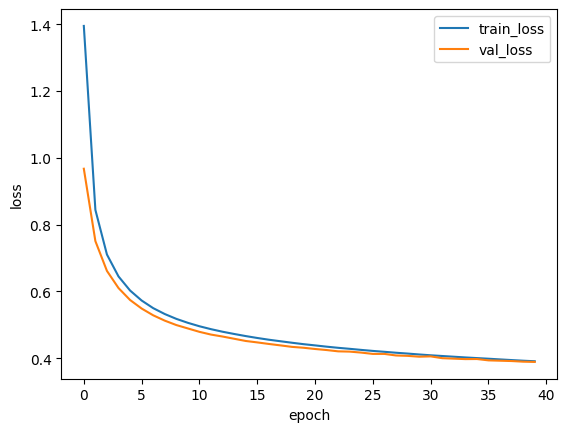

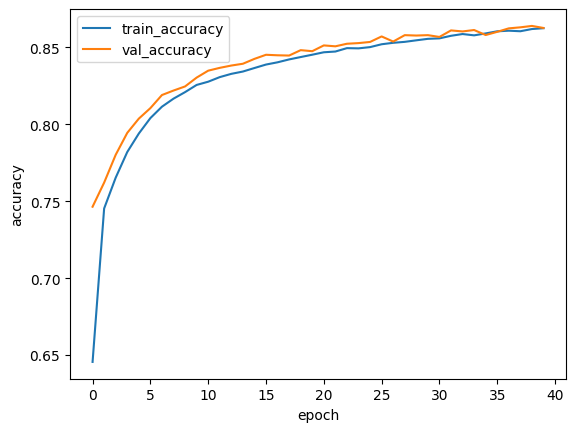

In [5]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

(x_train_all, y_train_all), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train_all, y_train_all, stratify=y_train_all, test_size=0.2, random_state=42)
x_train = x_train / 255
x_val = x_val / 255

# MultiClassNetwork는 1차원 배열을 입력으로 기대하므로, 28x28의 2차원인 패션 MNIST 데이터는 사용불가. 784의 1차원으로 변환 필요
x_train = x_train.reshape(-1, 784)
x_val = x_val.reshape(-1, 784)

y_train_encoded = tf.keras.utils.to_categorical(y_train)
y_val_encoded = tf.keras.utils.to_categorical(y_val)

model = Sequential()
model.add(Dense(100, activation='sigmoid', input_shape=(784,)))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train_encoded, epochs=40, validation_data=(x_val, y_val_encoded))

print(history.history.keys())

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train_loss', 'val_loss'])
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train_accuracy', 'val_accuracy'])
plt.show()
